In [109]:
import random
from collections import defaultdict
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
class OnlineTripartiteMatching:
    @staticmethod
    def epsilon_ranking(Vl, Vi, Vr, El, Er, order):
        Vl = set(Vl)
        Vi = set(Vi)
        Vr = set(Vr)
        
        matched = set()
        ranks = {i: random.uniform(0, 1) for i in Vi}
        Sm = set()
        M = []
        
        for d in order:
            if d in matched:
                continue
                
            isLeft = d in Vl
            oppositeSet = Vr if isLeft else Vl
            Nd = El.get(d, []) if isLeft else Er.get(d, [])
            
            Nd = [i for i in Nd if i not in matched]
            
            if not Nd:
                continue
            
            io = min(Nd, key=lambda i: ranks[i])
            seenI = {i for _, i in Sm} 
            
            for i in Nd:
                if i not in seenI:
                    Sm.add((d, i))
                    
            oppositesForIO = [o for o, i in Sm if i == io and o in oppositeSet and o not in matched]
            hasOpposite = bool(oppositesForIO)
            
            if hasOpposite:
                s1 = random.choice(oppositesForIO)
                l = d if isLeft else s1
                r = s1 if isLeft else d
                triplet = (l, io, r)
                M.append(triplet)
                matched.update({l, io, r})
                Sm = {(o, i) for o, i in Sm if o not in matched and i not in matched}
                continue
            
            possibleS2 = []
            for i in Nd:
                opposites = [o for o, ii in Sm if ii == i and o in oppositeSet and o not in matched]
                if opposites:
                    possibleS2.append(i)
                    
            if possibleS2:
                s2 = min(possibleS2, key=lambda i: ranks[i])
                oppositesForS2 = [o for o, i in Sm if i == s2 and o in oppositeSet and o not in matched]
                if oppositesForS2:
                    s1 = random.choice(oppositesForS2)
                    l = d if isLeft else s1
                    r = s1 if isLeft else d
                    triplet = (l, s2, r)
                    M.append(triplet)
                    matched.update({l, s2, r})
                    Sm = {(o, i) for o, i in Sm if o not in matched and i not in matched}
                    
        return M
    
    @staticmethod
    def greedy_matching(Vl, Vi, Vr, El, Er, order):
        Vl = set(Vl)
        Vi = set(Vi)
        Vr = set(Vr)
        
        matched = set()
        Sm = set()
        M = []
        
        for d in order:
            if d in matched:
                continue
                
            isLeft = d in Vl
            oppositeSet = Vr if isLeft else Vl
            Nd = El.get(d, []) if isLeft else Er.get(d, [])
            
            Nd = [i for i in Nd if i not in matched]
            
            if not Nd:
                continue
            
            possibleI = []
            for i in Nd:
                opposites = [o for o, ii in Sm if ii == i and o in oppositeSet and o not in matched]
                if opposites:
                    possibleI.append((i, opposites))
                    
            if possibleI:
                possibleI.sort(key=lambda x: x[0])
                chosenI, opposites = possibleI[0]
                s1 = random.choice(opposites)
                l = d if isLeft else s1
                r = s1 if isLeft else d
                triplet = (l, chosenI, r)
                M.append(triplet)
                matched.update({l, chosenI, r})
                Sm = {(o, i) for o, i in Sm if o not in matched and i not in matched}
            else:
                for i in Nd:
                    if (d, i) not in Sm:
                        Sm.add((d, i))
                    
        return M

In [111]:
def visualize_tripartite_graph(Vl, Vi, Vr, El, Er):
    G = nx.Graph()
    G.add_nodes_from(Vl, partition=0)
    G.add_nodes_from(Vi, partition=1)
    G.add_nodes_from(Vr, partition=2)
    
    for l, inters in El.items():
        for i in inters:
            G.add_edge(l, i)
    for r, inters in Er.items():
        for i in inters:
            G.add_edge(r, i)
            
    pos = nx.multipartite_layout(G, subset_key="partition")
    plt.figure(figsize=(12, 20))
    nx.draw(G, pos, with_labels=True, node_color=['lightblue' if n in Vl else 'lightgreen' if n in Vi else 'lightpink' for n in G.nodes()],
            node_size=500, font_size=8)
    plt.title("Tripartite Graph Visualization")
    plt.show()
    plt.close()

In [112]:
def load_ds(filepath, col1, col2, col3):
    ds = pd.read_csv(filepath)
    ds = ds[[col1, col2, col3]]
    
    Vl = ds[col1]
    Vi = ds[col2]
    Vr = ds[col3]
    
    El = defaultdict(list)
    Er = defaultdict(list)
    for c1, c2, c3 in ds.values:
        El[c1].append(c2)
        Er[c3].append(c2)
    
    return Vl, Vi, Vr, dict(El), dict(Er)

In [113]:
def generate_synthetic_random(n, p):
    Vl = [f'L{i}' for i in range(n)]
    Vi = [f'I{i}' for i in range(n)]
    Vr = [f'R{i}' for i in range(n)]
    
    El = defaultdict(list)
    for l in Vl:
        for i in Vi:
            if random.random() < p:
                El[l].append(i)
    
    Er = defaultdict(list)
    for r in Vr:
        for i in Vi:
            if random.random() < p:
                Er[r].append(i)
    
    return Vl, Vi, Vr, dict(El), dict(Er)

In [114]:
def generate_synthetic_nws(n, k, p):
    total_n = 3 * n
    G = nx.newman_watts_strogatz_graph(total_n, k, p)
    
    Vl = list(range(n))
    Vi = list(range(n, 2*n))
    Vr = list(range(2*n, 3*n))
    
    for u, v in list(G.edges):
        if (u in Vl and v in Vl) or (u in Vi and v in Vi) or (u in Vr and v in Vr) or (u in Vl and v in Vr) or (u in Vr and v in Vl):
            G.remove_edge(u, v)
    
    El = defaultdict(list)
    for l in Vl:
        for neigh in G.neighbors(l):
            if neigh in Vi:
                El[l].append(neigh)
    
    Er = defaultdict(list)
    for r in Vr:
        for neigh in G.neighbors(r):
            if neigh in Vi:
                Er[r].append(neigh)
                
    return [f'L{i}' for i in Vl], [f'I{i-n}' for i in Vi], [f'R{i-2*n}' for i in Vr], dict(El), dict(Er)

In [115]:
def simulate(Vl, Vi, Vr, El, Er, num_runs=10):
    opt = min(len(set(Vl)), len(set(Vi)), len(set(Vr)))
    print(f"Optimal matching size: {opt}")
    
    greedy_sizes = []
    epsilon_sizes = []
    
    for run in range(num_runs):
        arrival_order = list(Vl) + list(Vr)
        random.shuffle(arrival_order)
        
        M_greedy = OnlineTripartiteMatching.greedy_matching(Vl, Vi, Vr, El, Er, arrival_order)
        greedy_sizes.append(len(M_greedy))
        
        M_epsilon = OnlineTripartiteMatching.epsilon_ranking(Vl, Vi, Vr, El, Er, arrival_order)
        epsilon_sizes.append(len(M_epsilon))
        
        if run < 3:
            print(f"  Run {run+1}: Greedy={len(M_greedy)}, Epsilon={len(M_epsilon)}")
    
    avg_greedy = sum(greedy_sizes) / num_runs
    avg_epsilon = sum(epsilon_sizes) / num_runs
    
    print(f"\nAverage Greedy matching size: {avg_greedy}")
    print(f"Average Epsilon-RANKING matching size: {avg_epsilon}")


IAU dataset
Graph sizes: |Vl|=88, |Vi|=13, |Vr|=88


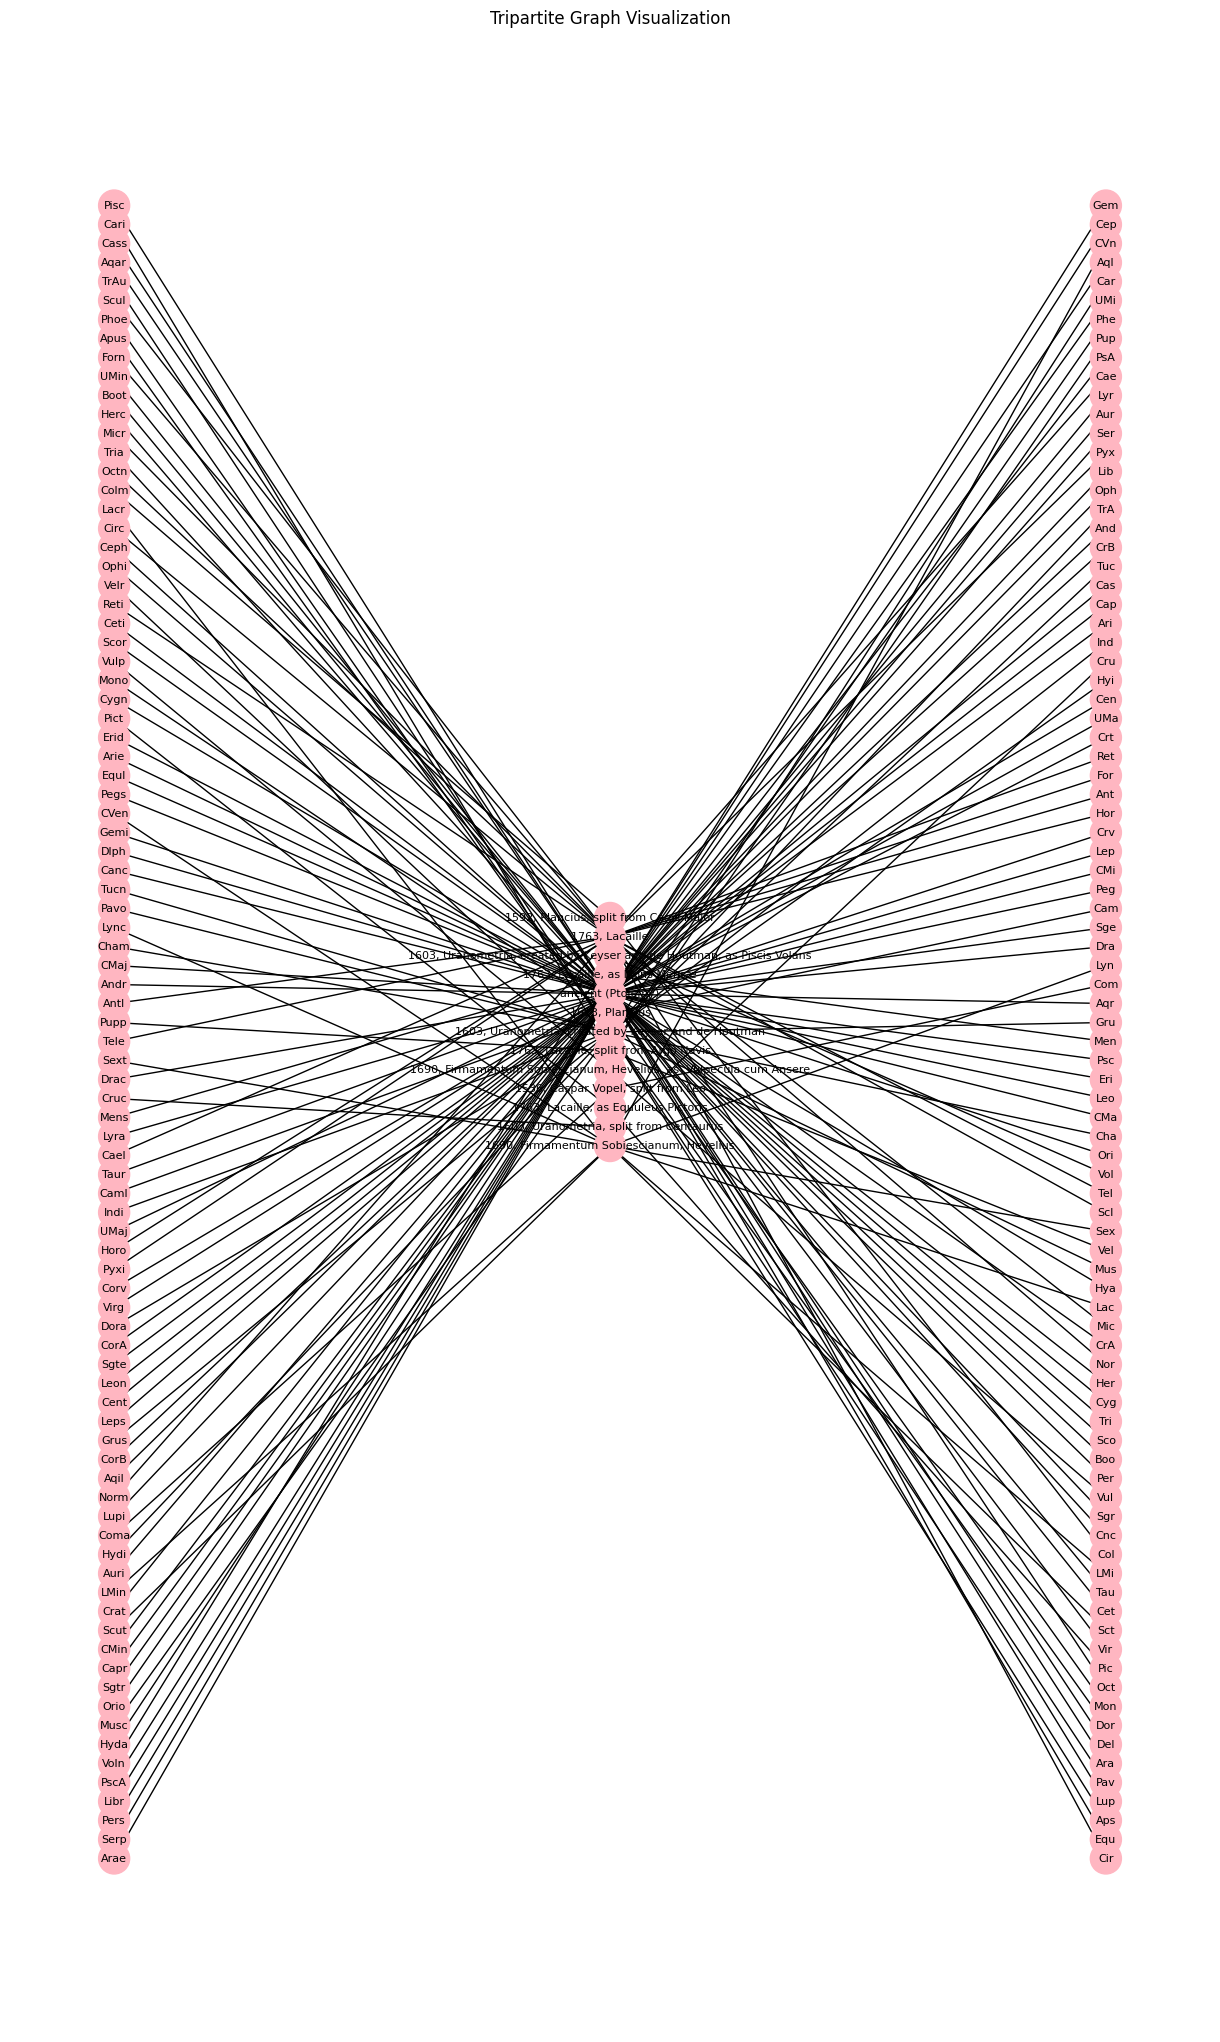

Optimal matching size: 13
  Run 1: Greedy=13, Epsilon=13
  Run 2: Greedy=13, Epsilon=13
  Run 3: Greedy=13, Epsilon=13

Average Greedy matching size: 13.0
Average Epsilon-RANKING matching size: 13.0


In [116]:
print("IAU dataset")
Vl, Vi, Vr, El, Er, = load_ds("./Dataset/constellation.csv", "NASA", "Origin", "IAU")
print(f"Graph sizes: |Vl|={len(set(Vl))}, |Vi|={len(set(Vi))}, |Vr|={len(set(Vr))}")
visualize_tripartite_graph(Vl, Vi, Vr, El, Er)
simulate(Vl, Vi, Vr, El, Er, num_runs=10)


DS Job Salaries


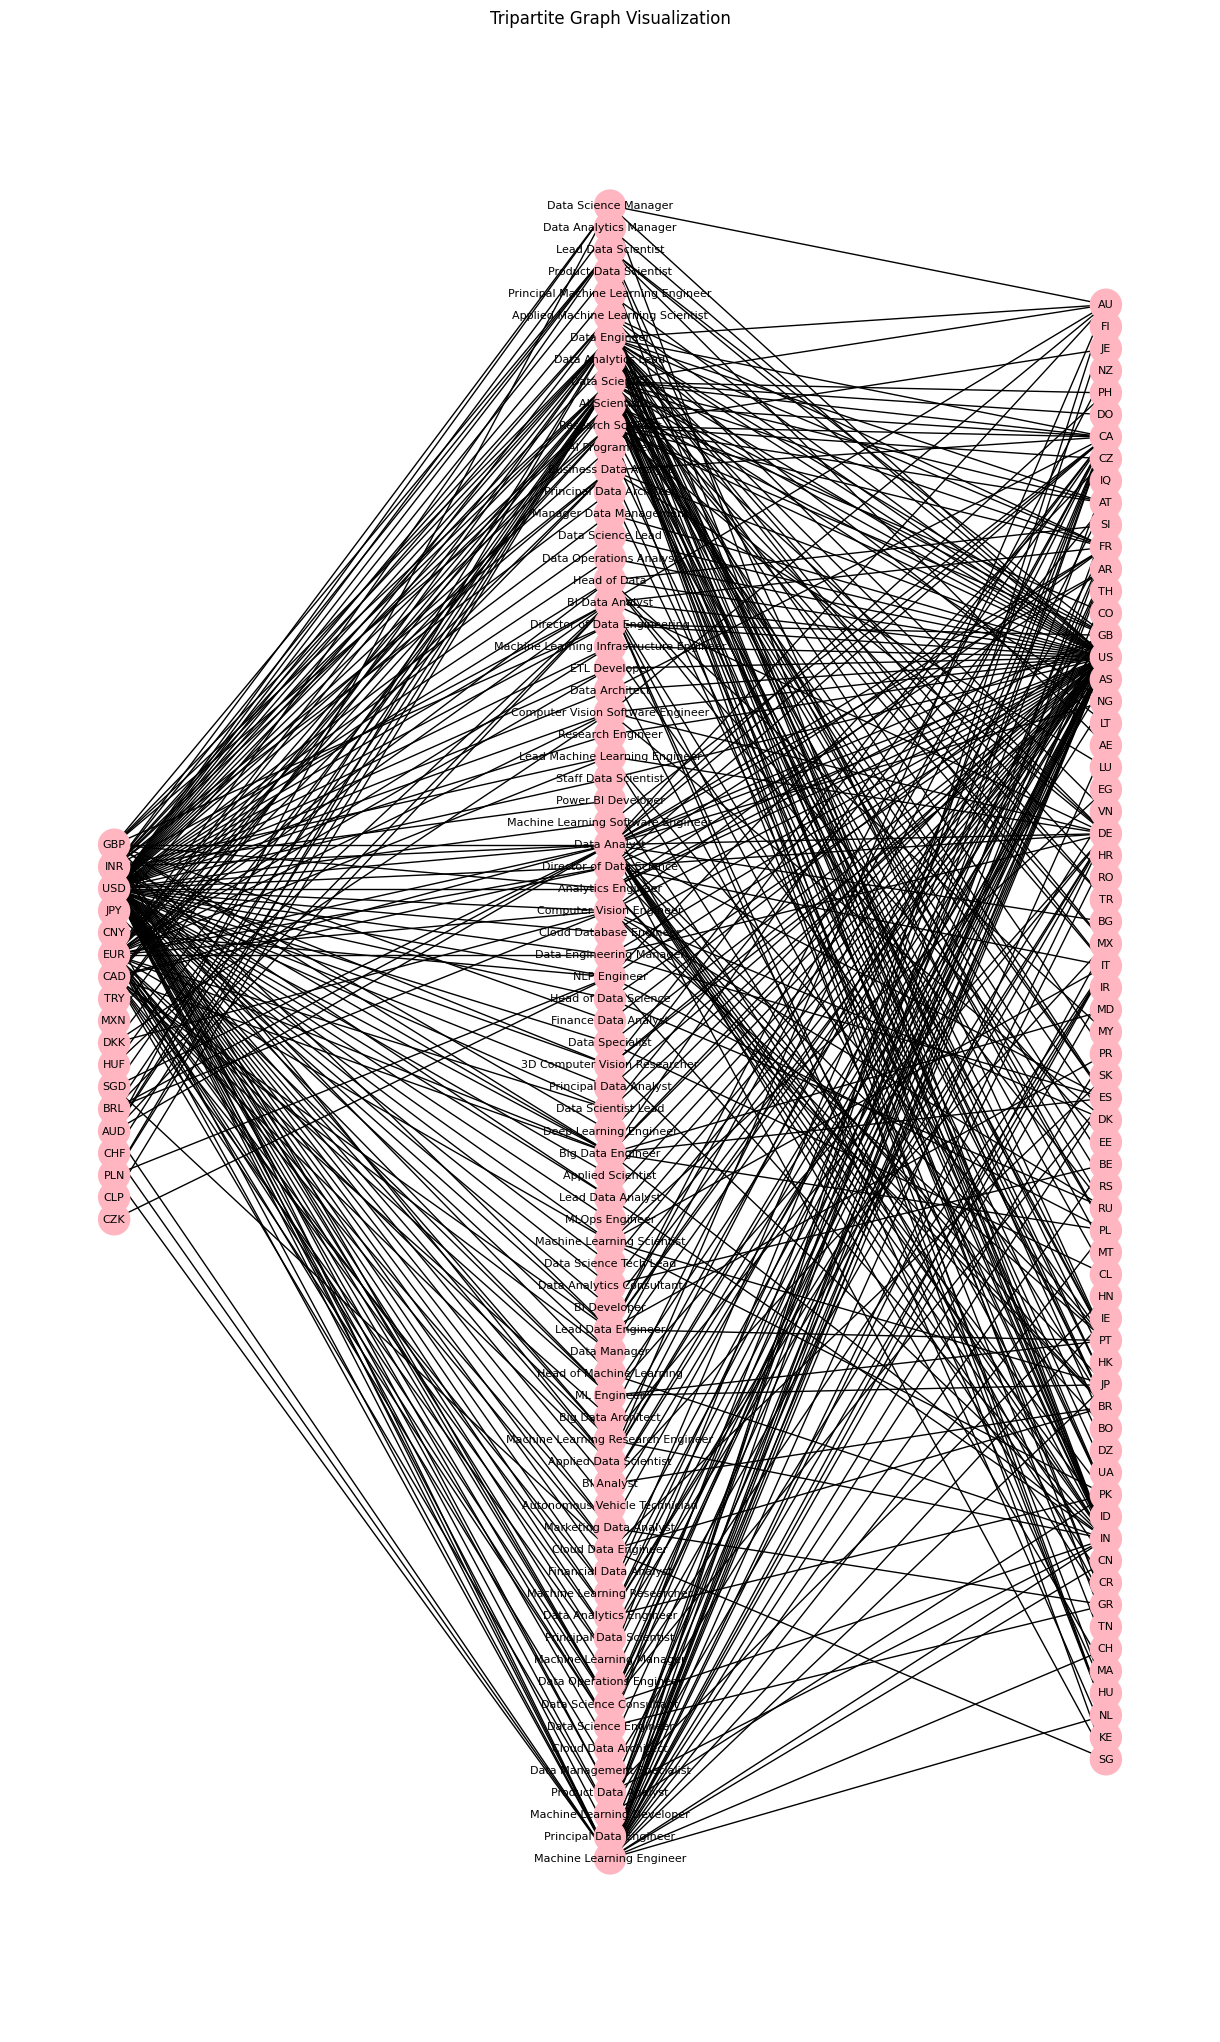

Optimal matching size: 18
  Run 1: Greedy=13, Epsilon=13
  Run 2: Greedy=13, Epsilon=15
  Run 3: Greedy=14, Epsilon=13

Average Greedy matching size: 13.3
Average Epsilon-RANKING matching size: 13.0


In [118]:
print("DS Job Salaries")
Vl, Vi, Vr, El, Er = load_ds("./Dataset/ds_salaries.csv", "salary_currency", "job_title", "employee_residence")
visualize_tripartite_graph(Vl, Vi, Vr, El, Er)
simulate(Vl, Vi, Vr, El, Er)